In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
from collections import Counter
import re


In [ ]:
df = pd.read_csv("/content/dataset_principal_atualizado.csv")

df.head()

,Noticia,Rotulo
0,Copom se reúne nesta quarta-feira; mercado fin...,fake
1,Riscos fiscal e político e crise sanitária imp...,fake
2,"Preço do arroz pode cair nas próximas semanas,...",fake
3,Preços do petróleo caem US$ 10/barril em maio...,fake
4,Banco Central mantém Selic a 2% ao ano \n\nco...,fake


In [ ]:
# presença de duplictas
print("Duplicatas completas:", df.duplicated().sum())
print("Notícias duplicadas:", df["Noticia"].duplicated().sum())

Duplicatas completas: 0
Notícias duplicadas: 0


In [ ]:
# presença de valores ausentes
df.isna().sum()

,0
Noticia,0
Rotulo,0


In [ ]:
conflitos = (
    df.groupby("Noticia")["Rotulo"]
      .nunique()
)

conflitos = conflitos[conflitos > 1]

print("Notícias com rótulos diferentes:", len(conflitos))

Notícias com rótulos diferentes: 0


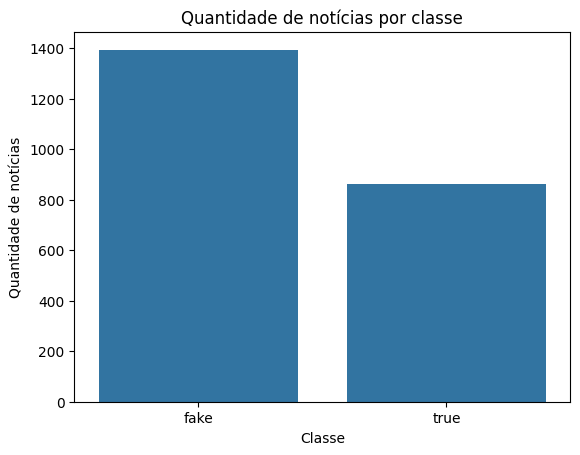

In [ ]:
sns.countplot(
    data=df,
    x="Rotulo"
)

plt.xlabel("Classe")
plt.ylabel("Quantidade de notícias")
plt.title("Quantidade de notícias por classe")
plt.show()

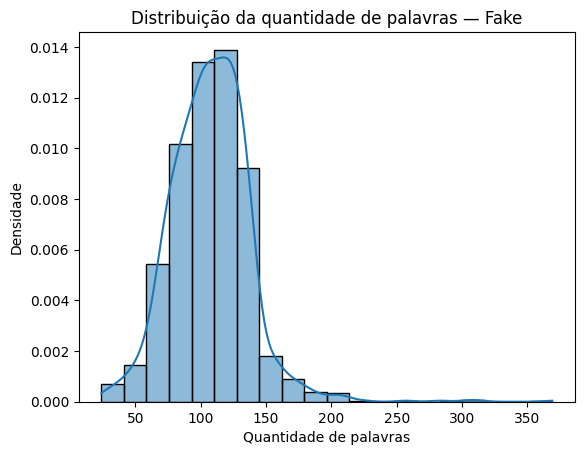

In [ ]:
sns.histplot(
    data=df[df["Rotulo"] == "fake"],
    x="quantidade_palavras",
    bins=20,
    stat="density",
    kde=True
)

plt.xlabel("Quantidade de palavras")
plt.ylabel("Densidade")
plt.title("Distribuição da quantidade de palavras — Fake")
plt.show()

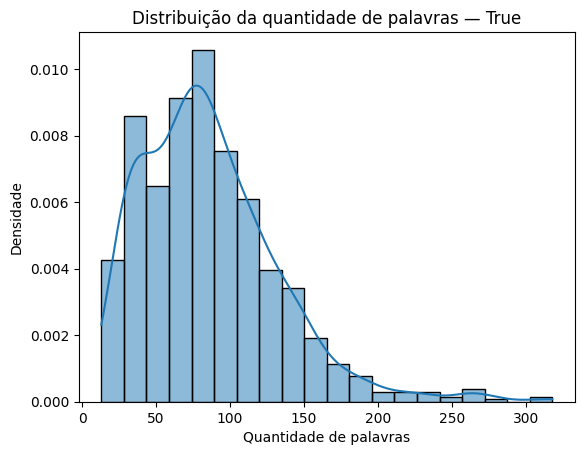

In [ ]:
sns.histplot(
    data=df[df["Rotulo"] == "true"],
    x="quantidade_palavras",
    bins=20,
    stat="density",
    kde=True
)

plt.xlabel("Quantidade de palavras")
plt.ylabel("Densidade")
plt.title("Distribuição da quantidade de palavras — True")
plt.show()

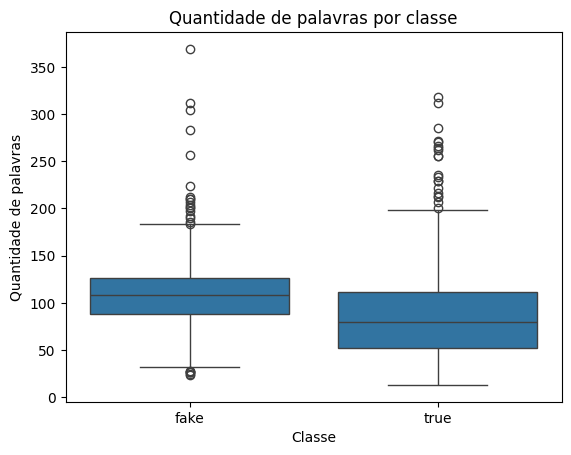

In [ ]:
sns.boxplot(
    data=df,
    x="Rotulo",
    y="quantidade_palavras"
)

plt.xlabel("Classe")
plt.ylabel("Quantidade de palavras")
plt.title("Quantidade de palavras por classe")
plt.show()

In [ ]:
nltk.download("stopwords")

stop_words = set(stopwords.words("portuguese"))

stop_words.update(["s", "sobre", "jair", "todo", "alem", "faz", "diz", "disse",
"luiz inácio", "r"])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


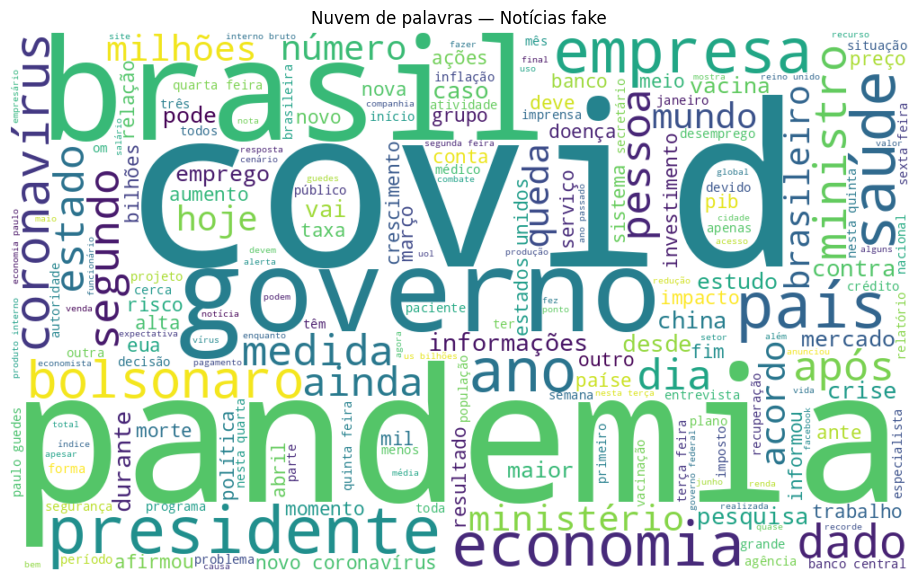

In [ ]:
texto_fake = " ".join(
    df.loc[df["Rotulo"] == "fake", "Noticia"]
    .dropna()
    .astype(str)
    .str.lower()
)

wordcloud_fake = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=stop_words
).generate(texto_fake)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — Notícias fake")
plt.show()

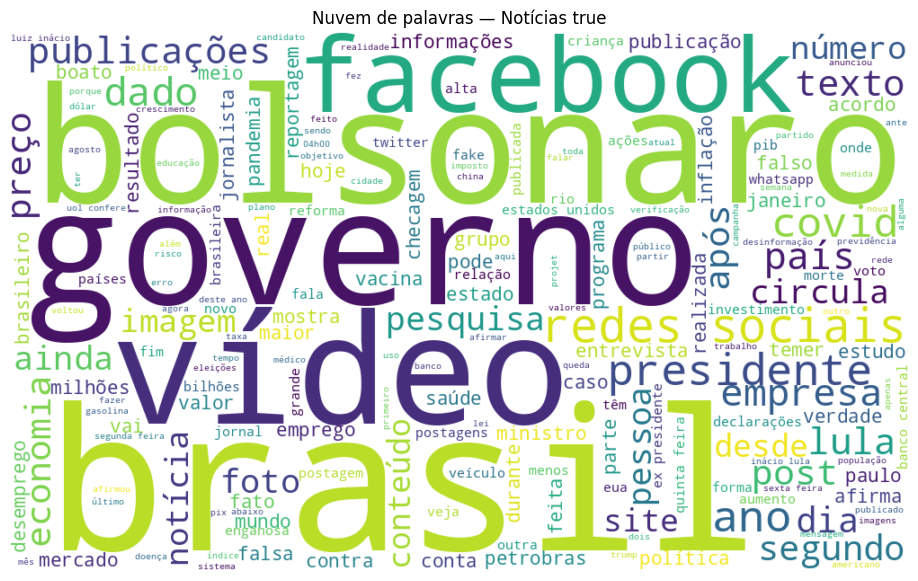

In [ ]:
texto_true = " ".join(
    df.loc[df["Rotulo"] == "true", "Noticia"]
    .dropna()
    .astype(str)
    .str.lower()
)

wordcloud_true = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    stopwords=stop_words
).generate(texto_true)

plt.figure(figsize=(12, 7))
plt.imshow(wordcloud_true, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — Notícias true")
plt.show()

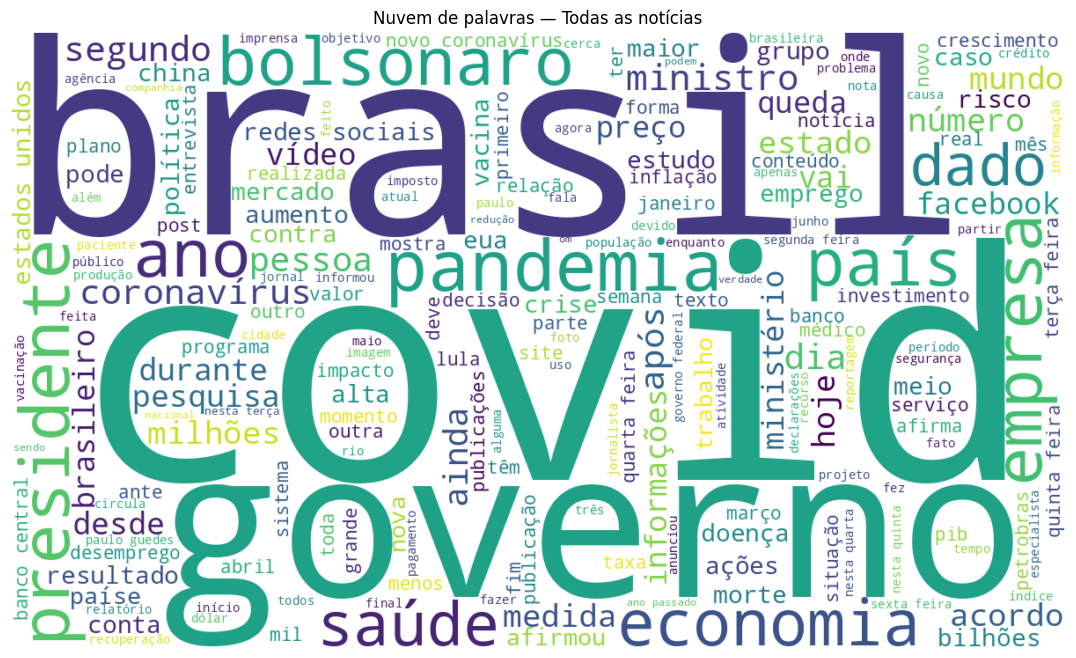

In [ ]:
texto_todas = " ".join(
    df["Noticia"]
    .dropna()
    .astype(str)
    .str.lower()
)

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=stop_words
).generate(texto_todas)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras — Todas as notícias")
plt.show()

In [ ]:
df.groupby("Rotulo")["quantidade_palavras"].describe()

,count,mean,std,min,25%,50%,75%,max
Rotulo,,,,,,,,
fake,1394.0,107.598278,30.508575,24.0,88.0,108.0,126.0,369.0
true,861.0,86.073171,46.576074,13.0,52.0,80.0,111.0,318.0
